In [2]:
!pip install kaggle -q
!mkdir -p ~/.kaggle

from google.colab import files
print("📁 Upload your kaggle.json file")
files.upload()

import shutil
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API configured successfully!")

📁 Upload your kaggle.json file


Saving kaggle.json to kaggle.json
✅ Kaggle API configured successfully!


In [3]:
import os
os.chdir('/content')

print("🔽 Downloading embryo dataset...")
!kaggle datasets download -d abhishekbuddiga06/embryo-dataset -q
!kaggle datasets download -d abhishekbuddiga06/embryo-dataset-annotations -q

print("📦 Extracting datasets...")
!unzip -q embryo-dataset.zip
!unzip -q embryo-dataset-annotations.zip

IMG_DIR = "/content/embryo_dataset/embryo_dataset"
ANNO_DIR = "/content/embryo_dataset_annotations/embryo_dataset_annotations"

print(f"✅ Dataset extracted successfully!")
print(f"   Images directory: {IMG_DIR}")
print(f"   Annotations directory: {ANNO_DIR}")
print(f"   Sample videos found: {len(os.listdir(IMG_DIR))}")


🔽 Downloading embryo dataset...
Dataset URL: https://www.kaggle.com/datasets/abhishekbuddiga06/embryo-dataset
License(s): unknown
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata
📦 Extracting datasets...
unzip:  cannot find or open embryo-dataset-annotations.zip, embryo-dataset-annotations.zip.zip or embryo-dataset-annotations.zip.ZIP.
✅ Dataset extracted successfully!
   Images directory: /content/embryo_dataset/embryo_dataset
   Annotations directory: /content/embryo_dataset_annotations/embryo_dataset_annotations
   Sample videos found: 704


In [4]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install scikit-learn pandas matplotlib pillow -q

print("✅ All dependencies installed!")

✅ All dependencies installed!


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
import gc
import time
from datetime import datetime
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True

IMG_DIR = "/content/embryo_dataset/embryo_dataset"
ANNO_DIR = "/content/embryo_dataset_annotations/embryo_dataset_annotations"

PHASES = ['tPB2', 'tPNa', 'tPNf', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tM', 'tSB', 'tB', 'tEB', 'tHB']
PHASE_TO_IDX = {phase: i for i, phase in enumerate(PHASES)}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


✅ Using device: cuda
   GPU: Tesla T4
   GPU Memory: 15.64 GB


In [6]:
!pip show sympy

Name: sympy
Version: 1.14.0
Summary: Computer algebra system (CAS) in Python
Home-page: https://sympy.org
Author: SymPy development team
Author-email: sympy@googlegroups.com
License: BSD
Location: /usr/local/lib/python3.12/dist-packages
Requires: mpmath
Required-by: quantecon, torch


In [7]:
class EmbryoDataset(Dataset):
    def __init__(self, img_dir, anno_dir, video_ids, transform=None, sample_rate=1):
        self.img_dir = img_dir
        self.anno_dir = anno_dir
        self.video_ids = video_ids
        self.transform = transform
        self.sample_rate = sample_rate
        self.samples = self._prepare_samples()

    def _prepare_samples(self):
        samples = []
        for vid in self.video_ids:
            csv_path = os.path.join(self.anno_dir, f"{vid}_phases.csv")
            vid_folder = os.path.join(self.img_dir, vid)

            if not os.path.exists(csv_path) or not os.path.exists(vid_folder):
                continue

            all_frames = sorted([f for f in os.listdir(vid_folder) if f.endswith('.jpeg')])
            if not all_frames:
                continue

            df = pd.read_csv(csv_path)
            for _, row in df.iterrows():
                phase_name = str(row.iloc[0]).strip()
                if phase_name in PHASE_TO_IDX:
                    label = float(PHASE_TO_IDX[phase_name])
                    start_idx, end_idx = int(row.iloc[1]), int(row.iloc[2])
                    for i in range(start_idx, end_idx + 1, self.sample_rate):
                        if i < len(all_frames):
                            samples.append((os.path.join(vid_folder, all_frames[i]), label))
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor([label], dtype=torch.float32)

print("✅ EmbryoDataset class defined!")

✅ EmbryoDataset class defined!


In [8]:
class EmbryoMobileNet(nn.Module):
    def __init__(self):
        super(EmbryoMobileNet, self).__init__()
        self.backbone = models.mobilenet_v2(weights='DEFAULT')
        num_ftrs = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_ftrs, 128),
            nn.ReLU(),
            nn.Linear(128, 16)
        )
    def forward(self, x):
        return self.backbone(x)

class EmbryoGoogLeNet(nn.Module):
    def __init__(self):
        super(EmbryoGoogLeNet, self).__init__()
        self.backbone = models.googlenet(weights='DEFAULT')
        self.backbone.aux_logits = False
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_ftrs, 128),
            nn.ReLU(),
            nn.Linear(128, 16)
        )
    def forward(self, x):
        return self.backbone(x)

'''class EmbryoInceptionV3(nn.Module):
    def __init__(self):
        super(EmbryoInceptionV3, self).__init__()
        self.backbone = models.inception_v3(weights='DEFAULT')
        self.backbone.aux_logits = False
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_ftrs, 128),
            nn.ReLU(),
            nn.Linear(128, 16)
        )
    def forward(self, x):
        return self.backbone(x)'''

class EmbryoVGG(nn.Module):
    def __init__(self, use_vgg19=False):
        super(EmbryoVGG, self).__init__()
        self.backbone = models.vgg19(weights='DEFAULT') if use_vgg19 else models.vgg16(weights='DEFAULT')
        for param in self.backbone.features.parameters():
            param.requires_grad = False
        num_ftrs = self.backbone.classifier[6].in_features
        self.backbone.classifier[6] = nn.Linear(num_ftrs, 16)
    def forward(self, x):
        return self.backbone(x)

print("✅ All model classes defined!")

✅ All model classes defined!


In [9]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

all_vids = [d for d in os.listdir(IMG_DIR) if os.path.isdir(os.path.join(IMG_DIR, d))]
print(f"📹 Total videos found: {len(all_vids)}")

train_vids, temp_vids = train_test_split(all_vids, test_size=0.3, random_state=42)
val_vids, test_vids = train_test_split(temp_vids, test_size=0.5, random_state=42)

print(f"   Training videos: {len(train_vids)}")
print(f"   Validation videos: {len(val_vids)}")
print(f"   Test videos: {len(test_vids)}")

SAMPLE_RATE = 10
BATCH_SIZE = 32
NUM_EPOCHS = 8

train_dataset = EmbryoDataset(IMG_DIR, ANNO_DIR, train_vids, transform=train_transforms, sample_rate=SAMPLE_RATE)
val_dataset = EmbryoDataset(IMG_DIR, ANNO_DIR, val_vids, transform=val_test_transforms, sample_rate=SAMPLE_RATE)

print(f"\n📊 Dataset Statistics:")
print(f"   Training samples: {len(train_dataset)}")
print(f"   Validation samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")

📹 Total videos found: 704
   Training videos: 492
   Validation videos: 106
   Test videos: 106

📊 Dataset Statistics:
   Training samples: 22286
   Validation samples: 4804
   Training batches: 697
   Validation batches: 151


In [10]:
alphas_to_test = [
    ("Baseline_CE", 1.0),
    ("Hybrid_MSE", 0.5)
]

models_to_train = [
    ("MobileNet", EmbryoMobileNet),
    ("GoogLeNet", EmbryoGoogLeNet),
    #("InceptionV3", EmbryoInceptionV3),
    ("VGG16", lambda: EmbryoVGG(use_vgg19=False)),
    ("VGG19", lambda: EmbryoVGG(use_vgg19=True))
]

ce_loss_fn = nn.CrossEntropyLoss()
mse_loss_fn = nn.MSELoss()
phase_indices = torch.arange(16, dtype=torch.float32).to(device)

print("="*80)
print("🚀 TRAINING CONFIGURATION SUMMARY")
print("="*80)
print(f"Total Runs Scheduled: {len(models_to_train) * len(alphas_to_test)}")
print(f"Total Epochs: {NUM_EPOCHS * len(models_to_train) * len(alphas_to_test)}")
print(f"Sample Rate: {SAMPLE_RATE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Number of Epochs: {NUM_EPOCHS}")
print("="*80)

🚀 TRAINING CONFIGURATION SUMMARY
Total Runs Scheduled: 8
Total Epochs: 64
Sample Rate: 10
Batch Size: 32
Number of Epochs: 8


In [11]:
output_dir = '/content/training_results'
os.makedirs(output_dir, exist_ok=True)

print(f"\nStarting Training Pipeline...")
print(f"Results will be saved to: {output_dir}")
print("="*80)
overall_start_time = time.time()

for model_name, ModelClass in models_to_train:
    for alpha_name, ALPHA in alphas_to_test:

        print(f"\n🚀 INITIALIZING: {model_name} | {alpha_name} (Alpha={ALPHA}) 🚀")
        print(f"Model-Run Starting Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

        model = ModelClass()
        if torch.cuda.device_count() > 1:
            model = nn.DataParallel(model)
        model = model.to(device)

        optimizer = optim.Adam(model.parameters(), lr=0.0001)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        checkpoint_path = f'{output_dir}/{model_name}_{alpha_name}.pth'

        history = {
            'train_loss': [],
            'train_exact_acc': [],
            'train_tol_acc': [],
            'val_loss': [],
            'val_exact_acc': [],
            'val_tol_acc': []
        }
        best_val_loss = float('inf')
        run_start_time = time.time()

        for epoch in range(NUM_EPOCHS):
            epoch_start_time = time.time()

            model.train()
            running_loss, exact_correct, tol_correct, total = 0.0, 0, 0, 0

            for i, (images, labels) in enumerate(train_loader):
                images, labels = images.to(device), labels.to(device)
                labels_long, labels_float = labels.squeeze().long(), labels.squeeze().float()

                optimizer.zero_grad()
                logits = model(images)

                loss_ce = ce_loss_fn(logits, labels_long)
                probs = F.softmax(logits, dim=1)
                expected_phase = torch.sum(probs * phase_indices, dim=1)
                loss_mse = mse_loss_fn(expected_phase, labels_float)

                loss = (ALPHA * loss_ce) + ((1 - ALPHA) * loss_mse)
                loss.backward()
                optimizer.step()

                preds = torch.argmax(logits, dim=1)
                total += labels.size(0)
                exact_correct += (preds == labels_long).sum().item()
                tol_correct += (torch.abs(preds - labels_long) <= 1).sum().item()
                running_loss += loss.item()

            history['train_loss'].append(running_loss / len(train_loader))
            history['train_exact_acc'].append(exact_correct / total)
            history['train_tol_acc'].append(tol_correct / total)

            model.eval()
            val_loss, val_exact, val_tol, val_total = 0.0, 0, 0, 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    labels_long, labels_float = labels.squeeze().long(), labels.squeeze().float()

                    logits = model(images)
                    loss_ce = ce_loss_fn(logits, labels_long)
                    probs = F.softmax(logits, dim=1)
                    expected_phase = torch.sum(probs * phase_indices, dim=1)
                    loss_mse = mse_loss_fn(expected_phase, labels_float)
                    loss = (ALPHA * loss_ce) + ((1 - ALPHA) * loss_mse)

                    preds = torch.argmax(logits, dim=1)
                    val_total += labels.size(0)
                    val_exact += (preds == labels_long).sum().item()
                    val_tol += (torch.abs(preds - labels_long) <= 1).sum().item()
                    val_loss += loss.item()

            current_val_loss = val_loss / len(val_loader)
            history['val_loss'].append(current_val_loss)
            history['val_exact_acc'].append(val_exact / val_total)
            history['val_tol_acc'].append(val_tol / val_total)
            scheduler.step(current_val_loss)

            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'history': history,
                    'best_val_loss': best_val_loss
                }, checkpoint_path)

            epoch_duration = time.time() - epoch_start_time
            elapsed_hours = int(epoch_duration // 3600)
            elapsed_minutes = int((epoch_duration % 3600) // 60)
            elapsed_seconds = epoch_duration % 60

            print(f"[{model_name} | {alpha_name}] Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
                  f"Time: {elapsed_hours}h {elapsed_minutes}m {elapsed_seconds:.1f}s | "
                  f"Train Loss: {history['train_loss'][-1]:.4f} | Train Tol: {history['train_tol_acc'][-1]:.2%} | "
                  f"Val Loss: {current_val_loss:.4f} | Val Tol: {history['val_tol_acc'][-1]:.2%}")

        plt.figure(figsize=(18, 5))

        plt.subplot(1, 3, 1)
        plt.plot(history['train_loss'], label='Train', color='red', marker='o')
        plt.plot(history['val_loss'], label='Val', color='darkred', marker='x', linestyle='--')
        plt.title(f'{model_name} ({alpha_name}) Combined Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 3, 2)
        plt.plot(history['train_exact_acc'], label='Train Exact', color='blue', marker='o')
        plt.plot(history['val_exact_acc'], label='Val Exact', color='darkblue', marker='x', linestyle='--')
        plt.title(f'{model_name} ({alpha_name}) Exact Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 3, 3)
        plt.plot(history['train_tol_acc'], label='Train Tol (±1)', color='green', marker='o')
        plt.plot(history['val_tol_acc'], label='Val Tol (±1)', color='darkgreen', marker='x', linestyle='--')
        plt.title(f'{model_name} ({alpha_name}) Tolerance Accuracy (±1)')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plot_path = f'{output_dir}/{model_name}_{alpha_name}_results.png'
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.close()

        run_duration = time.time() - run_start_time
        run_hours = int(run_duration // 3600)
        run_minutes = int((run_duration % 3600) // 60)
        run_seconds = int(run_duration % 60)

        print(f"\n✅ {model_name} ({alpha_name}) Completed!")
        print(f"Total Time for this Run: {run_hours}h {run_minutes}m {run_seconds}s")
        print(f"Plot saved to: {plot_path}")
        print(f"Checkpoint saved to: {checkpoint_path}")
        print(f"Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print("="*80)

        del model, optimizer, scheduler
        gc.collect()
        torch.cuda.empty_cache()

overall_duration = time.time() - overall_start_time
overall_hours = int(overall_duration // 3600)
overall_minutes = int((overall_duration % 3600) // 60)
overall_seconds = int(overall_duration % 60)

print("\n" + "="*80)
print("🎉 TRAINING COMPLETED SUCCESSFULLY! 🎉")
print("="*80)
print(f"Total Training Time: {overall_hours}h {overall_minutes}m {overall_seconds}s")
print(f"Final Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Results saved in: {output_dir}")
print("="*80)


Starting Training Pipeline...
Results will be saved to: /content/training_results

🚀 INITIALIZING: MobileNet | Baseline_CE (Alpha=1.0) 🚀
Model-Run Starting Time: 2026-04-08 18:35:07
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 103MB/s] 


[MobileNet | Baseline_CE] Epoch  1/8 | Time: 0h 3m 8.2s | Train Loss: 1.9837 | Train Tol: 51.30% | Val Loss: 1.7896 | Val Tol: 56.27%
[MobileNet | Baseline_CE] Epoch  2/8 | Time: 0h 2m 30.2s | Train Loss: 1.7357 | Train Tol: 59.29% | Val Loss: 1.7293 | Val Tol: 59.76%
[MobileNet | Baseline_CE] Epoch  3/8 | Time: 0h 2m 26.9s | Train Loss: 1.6681 | Train Tol: 61.23% | Val Loss: 1.7119 | Val Tol: 59.08%
[MobileNet | Baseline_CE] Epoch  4/8 | Time: 0h 2m 29.7s | Train Loss: 1.6172 | Train Tol: 62.53% | Val Loss: 1.7209 | Val Tol: 58.72%
[MobileNet | Baseline_CE] Epoch  5/8 | Time: 0h 2m 27.2s | Train Loss: 1.5755 | Train Tol: 64.06% | Val Loss: 1.7251 | Val Tol: 59.47%
[MobileNet | Baseline_CE] Epoch  6/8 | Time: 0h 2m 28.9s | Train Loss: 1.5359 | Train Tol: 65.11% | Val Loss: 1.7380 | Val Tol: 59.39%
[MobileNet | Baseline_CE] Epoch  7/8 | Time: 0h 2m 27.3s | Train Loss: 1.4773 | Train Tol: 66.78% | Val Loss: 1.7085 | Val Tol: 61.07%
[MobileNet | Baseline_CE] Epoch  8/8 | Time: 0h 2m 32.0s

100%|██████████| 49.7M/49.7M [00:00<00:00, 101MB/s]


[GoogLeNet | Baseline_CE] Epoch  1/8 | Time: 0h 2m 30.5s | Train Loss: 1.9277 | Train Tol: 53.51% | Val Loss: 1.8047 | Val Tol: 53.46%
[GoogLeNet | Baseline_CE] Epoch  2/8 | Time: 0h 2m 31.5s | Train Loss: 1.7074 | Train Tol: 59.59% | Val Loss: 1.7170 | Val Tol: 59.99%
[GoogLeNet | Baseline_CE] Epoch  3/8 | Time: 0h 2m 30.1s | Train Loss: 1.6490 | Train Tol: 61.81% | Val Loss: 1.7275 | Val Tol: 59.37%
[GoogLeNet | Baseline_CE] Epoch  4/8 | Time: 0h 2m 29.7s | Train Loss: 1.6044 | Train Tol: 63.21% | Val Loss: 1.6843 | Val Tol: 60.82%
[GoogLeNet | Baseline_CE] Epoch  5/8 | Time: 0h 2m 30.1s | Train Loss: 1.5635 | Train Tol: 64.32% | Val Loss: 1.6645 | Val Tol: 63.09%
[GoogLeNet | Baseline_CE] Epoch  6/8 | Time: 0h 2m 32.8s | Train Loss: 1.5344 | Train Tol: 65.48% | Val Loss: 1.7328 | Val Tol: 60.03%
[GoogLeNet | Baseline_CE] Epoch  7/8 | Time: 0h 2m 32.7s | Train Loss: 1.4958 | Train Tol: 66.33% | Val Loss: 1.7021 | Val Tol: 61.82%
[GoogLeNet | Baseline_CE] Epoch  8/8 | Time: 0h 2m 29.7

100%|██████████| 528M/528M [00:04<00:00, 113MB/s]


[VGG16 | Baseline_CE] Epoch  1/8 | Time: 0h 3m 10.5s | Train Loss: 2.2060 | Train Tol: 42.48% | Val Loss: 2.1090 | Val Tol: 47.27%
[VGG16 | Baseline_CE] Epoch  2/8 | Time: 0h 4m 4.3s | Train Loss: 2.0512 | Train Tol: 48.04% | Val Loss: 2.0538 | Val Tol: 49.10%
[VGG16 | Baseline_CE] Epoch  3/8 | Time: 0h 4m 39.9s | Train Loss: 1.9948 | Train Tol: 49.76% | Val Loss: 2.0457 | Val Tol: 48.61%
[VGG16 | Baseline_CE] Epoch  4/8 | Time: 0h 4m 3.3s | Train Loss: 1.9660 | Train Tol: 51.04% | Val Loss: 2.0391 | Val Tol: 48.58%
[VGG16 | Baseline_CE] Epoch  5/8 | Time: 0h 3m 57.6s | Train Loss: 1.9381 | Train Tol: 51.90% | Val Loss: 2.0189 | Val Tol: 48.67%
[VGG16 | Baseline_CE] Epoch  6/8 | Time: 0h 2m 56.9s | Train Loss: 1.9170 | Train Tol: 52.43% | Val Loss: 2.0369 | Val Tol: 51.06%
[VGG16 | Baseline_CE] Epoch  7/8 | Time: 0h 4m 5.1s | Train Loss: 1.8957 | Train Tol: 53.18% | Val Loss: 2.0034 | Val Tol: 51.37%
[VGG16 | Baseline_CE] Epoch  8/8 | Time: 0h 2m 55.5s | Train Loss: 1.8906 | Train Tol:

100%|██████████| 548M/548M [00:03<00:00, 166MB/s]


[VGG19 | Baseline_CE] Epoch  1/8 | Time: 0h 4m 22.1s | Train Loss: 2.2118 | Train Tol: 41.86% | Val Loss: 2.1148 | Val Tol: 45.27%
[VGG19 | Baseline_CE] Epoch  2/8 | Time: 0h 4m 46.9s | Train Loss: 2.0599 | Train Tol: 47.37% | Val Loss: 2.0690 | Val Tol: 47.90%
[VGG19 | Baseline_CE] Epoch  3/8 | Time: 0h 3m 14.8s | Train Loss: 2.0152 | Train Tol: 48.95% | Val Loss: 2.1076 | Val Tol: 49.04%
[VGG19 | Baseline_CE] Epoch  4/8 | Time: 0h 3m 14.3s | Train Loss: 1.9806 | Train Tol: 50.16% | Val Loss: 2.0888 | Val Tol: 47.84%
[VGG19 | Baseline_CE] Epoch  5/8 | Time: 0h 4m 22.5s | Train Loss: 1.9616 | Train Tol: 50.49% | Val Loss: 2.0630 | Val Tol: 48.33%
[VGG19 | Baseline_CE] Epoch  6/8 | Time: 0h 4m 13.2s | Train Loss: 1.9429 | Train Tol: 51.52% | Val Loss: 2.0409 | Val Tol: 49.17%
[VGG19 | Baseline_CE] Epoch  7/8 | Time: 0h 4m 18.7s | Train Loss: 1.9281 | Train Tol: 51.80% | Val Loss: 1.9914 | Val Tol: 49.92%
[VGG19 | Baseline_CE] Epoch  8/8 | Time: 0h 3m 15.7s | Train Loss: 1.9218 | Train T

In [12]:
from google.colab import files
import shutil

!cd /content && zip -r training_results.zip training_results/
files.download('/content/training_results.zip')

print("Results downloaded!")

  adding: training_results/ (stored 0%)
  adding: training_results/MobileNet_Hybrid_MSE_results.png (deflated 9%)
  adding: training_results/VGG19_Baseline_CE_results.png (deflated 8%)
  adding: training_results/GoogLeNet_Baseline_CE.pth (deflated 8%)
  adding: training_results/VGG19_Hybrid_MSE.pth (deflated 27%)
  adding: training_results/VGG16_Baseline_CE_results.png (deflated 7%)
  adding: training_results/GoogLeNet_Baseline_CE_results.png (deflated 7%)
  adding: training_results/VGG16_Hybrid_MSE_results.png (deflated 8%)
  adding: training_results/VGG16_Baseline_CE.pth (deflated 30%)
  adding: training_results/MobileNet_Hybrid_MSE.pth (deflated 8%)
  adding: training_results/GoogLeNet_Hybrid_MSE_results.png (deflated 9%)
  adding: training_results/MobileNet_Baseline_CE_results.png (deflated 8%)
  adding: training_results/VGG19_Baseline_CE.pth (deflated 30%)
  adding: training_results/VGG16_Hybrid_MSE.pth (deflated 28%)
  adding: training_results/VGG19_Hybrid_MSE_results.png (deflat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Results downloaded!



================ GoogLeNet_Baseline_CE_results.png =================



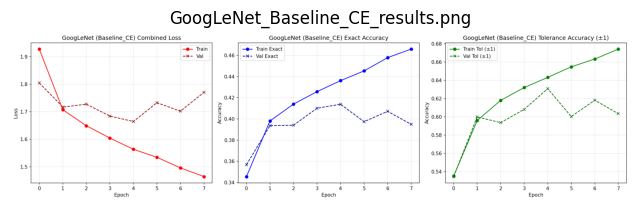


================ GoogLeNet_Hybrid_MSE_results.png =================



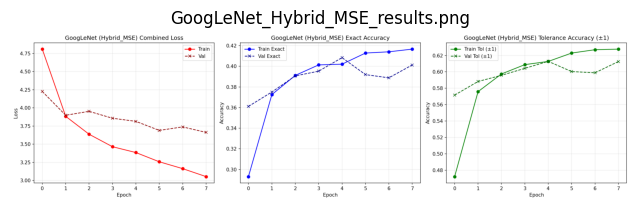


================ MobileNet_Baseline_CE_results.png =================



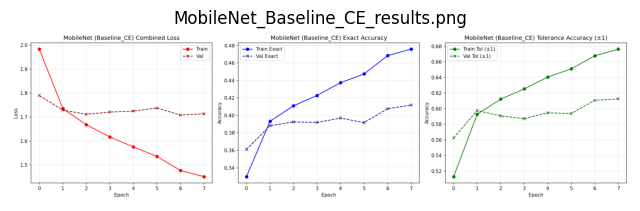


================ MobileNet_Hybrid_MSE_results.png =================



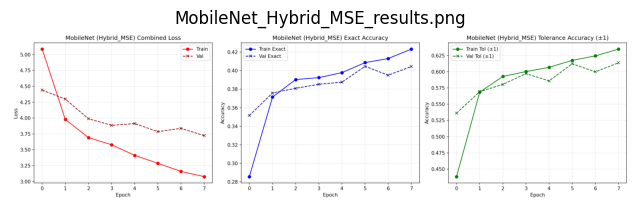


================ VGG16_Baseline_CE_results.png =================



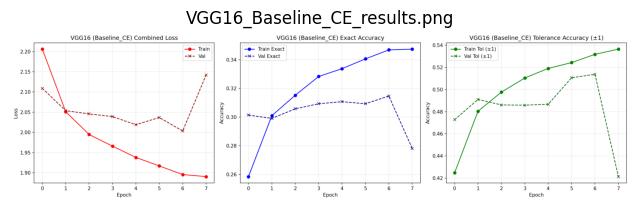


================ VGG16_Hybrid_MSE_results.png =================



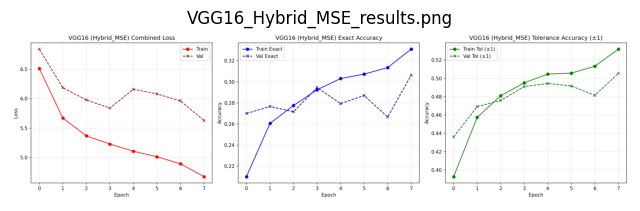


================ VGG19_Baseline_CE_results.png =================



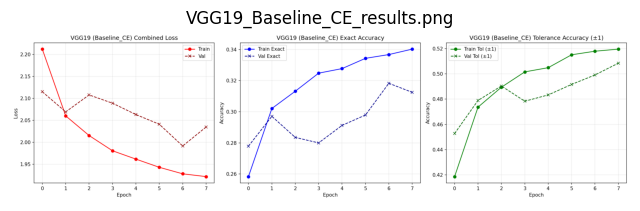


================ VGG19_Hybrid_MSE_results.png =================



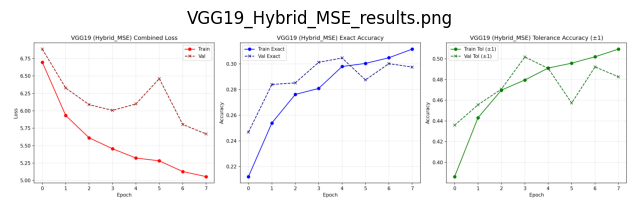

In [24]:
from collections import defaultdict
import os
from PIL import Image
import matplotlib.pyplot as plt

groups = defaultdict(list)

for f in files:
    model = f.split('_\n')[0]
    groups[model].append(f)

for model in sorted(groups.keys()):
    print(f"\n================ {model} =================\n")

    for file in sorted(groups[model]):
        #print(f" {file}")

        img = Image.open(os.path.join(output_dir, file))

        plt.figure(figsize=(8,4))
        plt.imshow(img)
        plt.title(file)
        plt.axis('off')
        plt.show()